In [159]:
# Imports necessary programs, as well as the dataset to be worked with.
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
cafedata = pd.DataFrame(pd.read_csv('dirty_cafe_sales.csv'))
pd.set_option('display.max_columns', None)

In [160]:
# Sorts values by Transaction ID to obtain an estimated date order, and replaces all missing values with np.nan to make later calculations much easier.
cafedata.sort_values(by='Transaction ID', inplace=True)
cafedata.reset_index(drop=True, inplace=True)
cafedata.replace(['UNKNOWN', 'ERROR'], np.nan, inplace=True)

In [161]:
cafedata.sample(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
1042,TXN_1950008,Smoothie,4,4.0,16.0,Digital Wallet,In-store,2023-07-24
6283,TXN_6609572,NaN,4,4.0,16.0,Cash,In-store,2023-06-15
8380,TXN_8515063,NaN,3,1.0,3.0,NaN,Takeaway,2023-12-06
7676,TXN_7893709,NaN,4,3.0,12.0,Credit Card,NaN,2023-03-14
4623,TXN_5114283,Tea,1,1.5,1.5,Digital Wallet,In-store,2023-05-28
8659,TXN_8786479,Coffee,4,2.0,8.0,NaN,NaN,2023-05-29
8349,TXN_8488298,Cake,3,3.0,9.0,Cash,NaN,2023-11-03
8084,TXN_8239121,Smoothie,NaN,4.0,4.0,NaN,In-store,2023-05-11
2126,TXN_2879791,Sandwich,1,4.0,4.0,NaN,NaN,2023-07-10
9119,TXN_9201988,Coffee,3,2.0,6.0,NaN,NaN,2023-05-14


In [162]:
# Establishes a canon price guide according to the website source, then fills accordingly for item price when it can.
price_guide = {
    'Sandwich': 4.0,
    'Tea': 1.5,
    'Coffee': 2.0,
    'Salad': 5.0,
    'Cake': 3.0,
    'Cookie': 1.0,
    'Smoothie': 4.0,
    'Juice': 3.0
}
for i in range(len(cafedata)):
    if cafedata['Item'].values[i] in price_guide.keys():
        cafedata['Price Per Unit'].values[i] = price_guide[cafedata['Item'].values[i]]

In [163]:
# Sets the numeric values to floats, then uses their dependence on each other to fill in missing values when only one of three values is missing.
cafedata[['Quantity', 'Total Spent', 'Price Per Unit']] = cafedata[['Quantity', 'Total Spent', 'Price Per Unit']].astype(float)
cafedata.fillna({'Quantity': cafedata['Total Spent'] / cafedata['Price Per Unit']}, inplace=True)
cafedata.fillna({'Price Per Unit': cafedata['Total Spent'] / cafedata['Quantity']}, inplace=True)
cafedata.fillna({'Total Spent': cafedata['Quantity'] * cafedata['Price Per Unit']}, inplace=True)

In [164]:
# Fills null dates with the previous transaction's date to attempt to get the values close enough - unfortunately, the Transaction IDs aren't in date order! Then sets the format to datetime.
cafedata['Transaction Date'] = cafedata['Transaction Date'].ffill()
cafedata['Transaction Date'] = pd.to_datetime(cafedata['Transaction Date'])

In [165]:
# For uniquely priced items, retroactively sets the item value from the price per item.
for i in range(len(cafedata)):
    if cafedata['Price Per Unit'].values[i] in [1.0, 1.5, 2.0, 5.0]:
        cafedata['Item'].values[i] = list(price_guide.keys())[list(price_guide.values()).index(cafedata['Price Per Unit'].values[i])]

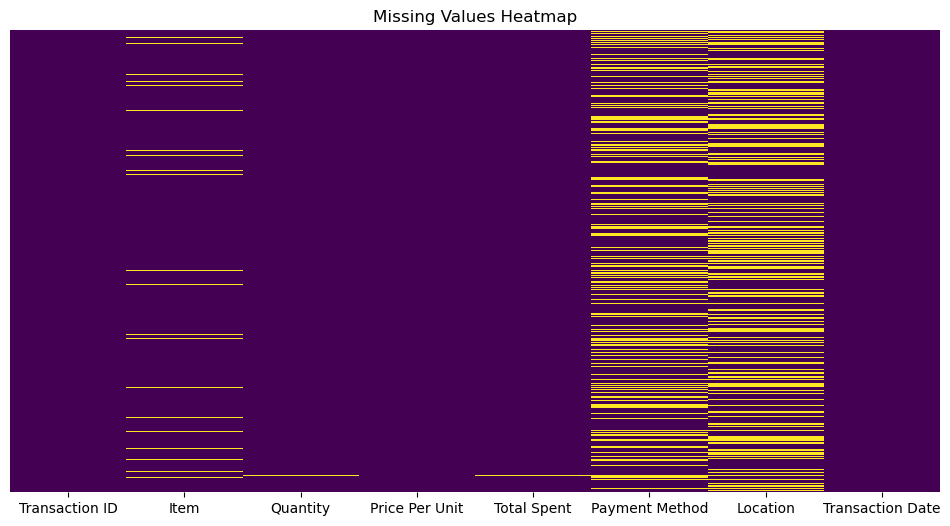

In [166]:
# Visualize missingness
plt.figure(figsize=(12,6))
sns.heatmap(cafedata.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [167]:
# At this point, we are out of values to fill in with other information. 
# A key decision: impute values and risk getting false data, remove missing values and lose a lot of data, or mark as unknown?
# For payment method and location, we will keep null, because they are not as essential for computing total revenue. (Can use rate metrics to infer later on)
# For numeric data, it's time to impute! Out of 10,000 transactions, only 23 are missing Total Spent data, which means inferrals should not overall impact data analysis.
# For this imputation, we will use K-Nearest Neighbors, and thus will have to prep our categorical variables as dummies.
cafedata['Year'] = cafedata['Transaction Date'].dt.year
cafedata['Month'] = cafedata['Transaction Date'].dt.month
cafedata['Weekday'] = cafedata['Transaction Date'].dt.weekday
cafedata['Day'] = cafedata['Transaction Date'].dt.day
cafedata = pd.concat([cafedata, pd.get_dummies(cafedata['Item']).astype(int)], axis=1)
cafedata = pd.concat([cafedata, pd.get_dummies(cafedata['Payment Method']).astype(int)], axis=1)
cafedata = pd.concat([cafedata, pd.get_dummies(cafedata['Location']).astype(int)], axis=1)

In [170]:
cafedata['Quantity'].value_counts()

Quantity
5.0    2114
2.0    2058
3.0    1952
4.0    1945
1.0    1931
Name: count, dtype: int64

In [169]:
# KNN Imputation for Numerical Features
from sklearn.impute import KNNImputer

# Select numerical columns (after removing near-zero variance features)
num_cols = cafedata.select_dtypes(include=[np.number]).columns

# Initialize the imputer
imputer = KNNImputer(n_neighbors=1)
cafedata[num_cols] = imputer.fit_transform(cafedata[num_cols])

print("Missing values after KNN imputation (numerical):")
print(cafedata[num_cols].isnull().sum())

Missing values after KNN imputation (numerical):
Quantity          0
Price Per Unit    0
Total Spent       0
Year              0
Month             0
Weekday           0
Day               0
Cake              0
Coffee            0
Cookie            0
Juice             0
Salad             0
Sandwich          0
Smoothie          0
Tea               0
Cash              0
Credit Card       0
Digital Wallet    0
In-store          0
Takeaway          0
dtype: int64


In [171]:
cafedata.sample(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Weekday,Day,Cake,Coffee,Cookie,Juice,Salad,Sandwich,Smoothie,Tea,Cash,Credit Card,Digital Wallet,In-store,Takeaway
7428,TXN_7653946,Smoothie,4.0,4.0,16.0,Cash,NaN,2023-09-19,2023.0,9.0,1.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
6586,TXN_6869880,Juice,4.0,3.0,12.0,Digital Wallet,Takeaway,2023-08-05,2023.0,8.0,5.0,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
9469,TXN_9518691,Salad,2.0,5.0,10.0,Credit Card,NaN,2023-03-30,2023.0,3.0,3.0,30.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7074,TXN_7349319,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-03-10,2023.0,3.0,4.0,10.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9421,TXN_9480564,Cookie,4.0,1.0,4.0,Cash,In-store,2023-06-12,2023.0,6.0,0.0,12.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5777,TXN_6177161,Tea,5.0,1.5,7.5,Credit Card,In-store,2023-04-01,2023.0,4.0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
6912,TXN_7205840,Salad,3.0,5.0,15.0,NaN,NaN,2023-03-05,2023.0,3.0,6.0,5.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3295,TXN_3919225,Cake,2.0,3.0,6.0,Cash,In-store,2023-03-26,2023.0,3.0,6.0,26.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4989,TXN_5446085,Coffee,3.0,2.0,6.0,Digital Wallet,NaN,2023-09-16,2023.0,9.0,5.0,16.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8599,TXN_8725721,Sandwich,1.0,4.0,4.0,Cash,NaN,2023-06-04,2023.0,6.0,6.0,4.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
